<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/MLexp2LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Discriminant Analysis (LDA)**

---




## 1. Core Concepts: Dimension & Dimensionality Reduction

### What is a Dimension?
- In machine learning, a dimension = a feature/variable in the dataset.  
- Example: If data = (height, weight, age), it has 3 dimensions.

### What is Dimensionality Reduction?
- Process of reducing the number of features while retaining useful information.

| Type | Goal | Example |
|------|------|---------|
| Feature Selection | Choose subset of original features | Selecting top 3 predictive columns |
| Feature Extraction | Create new features from old ones | PCA, LDA |

### Why Needed?
- **Curse of Dimensionality**: High dimensions need more data, risk of overfitting.  
- **Noise & Redundancy**: Many features may be useless.  
- **Computation**: Fewer features → faster training, smaller storage.  
- **Visualization**: Easier to plot in 2D/3D.


## 2. Linear Discriminant Analysis (LDA) - Theory

### Definition & Goal
- **Supervised** dimensionality reduction technique.
- Goal: Project data onto a lower-dimensional space where **classes are maximally separated**.

---

### Fisher Criterion

The objective function in LDA is:

$$
J(w) = \frac{w^T S_b w}{w^T S_w w}
$$

Where:  
- $S_w$ = Within-class scatter (compact classes).  
- $S_b$ = Between-class scatter (spread between means).  

---

### Steps
1. Compute class means and overall mean.  
2. Compute scatter matrices:
   - $S_w$: Within-class scatter.  
   - $S_b$: Between-class scatter.  
3. Solve eigenvalue problem:

$$
S_w^{-1} S_b w = \lambda w
$$

4. Select eigenvectors with largest eigenvalues → projection matrix.  

---

### Special Case (Two Classes)

For $C = 2$, the optimal projection vector is:

$$
w \propto S_w^{-1} (m_1 - m_2)
$$

---

### Resulting Dimensions
LDA reduces data to at most $C - 1$ dimensions.  

Example: Iris dataset has $C = 3 \implies 2$ dimensions.


## 3. LDA vs PCA

| Feature | PCA (Principal Component Analysis) | LDA (Linear Discriminant Analysis) |
|---------|-----------------------------------|------------------------------------|
| Type    | Unsupervised | Supervised |
| Goal    | Capture maximum variance | Maximize class separation |
| Labels Used? | No | Yes |
| Max Output Dims | Any ≤ d | C−1 |
| Useful For | Compression, feature engineering | Classification |


## 5. Importance of Standardization

- If features have very different scales (e.g., salary vs height), larger-scaled features dominate the scatter matrices.
- Always **standardize (Z-score)** before applying LDA/PCA.


# **Linear Discriminant Analysis (LDA) - Introduction**

Linear Discriminant Analysis (LDA) is a **supervised dimensionality reduction technique**.  
Unlike **Principal Component Analysis (PCA)**, which is unsupervised and maximizes variance regardless of labels,  
LDA explicitly **uses class labels** to maximize the **class separability**.

Formally, LDA aims to project high-dimensional data `X ∈ ℝ^(n×d)` onto a lower-dimensional space `Y ∈ ℝ^(n×k)` (with `k < d`),  
such that:

- **Within-class scatter** is minimized (points of the same class cluster together).
- **Between-class scatter** is maximized (class means are far apart).

Mathematically, LDA solves the optimization problem:

\[
W = \arg \max_W \frac{|W^T S_b W|}{|W^T S_w W|}
\]

where  
- \( S_w \) = within-class scatter matrix  
- \( S_b \) = between-class scatter matrix  
- \( W \) = projection matrix containing the optimal discriminant directions.

In this notebook, we will build LDA **from scratch** and then compare results with `scikit-learn`’s implementation.


In [ ]:
#Importing Data and Functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn import datasets
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# **Dataset Selection**

For LDA, we require **labeled data** with multiple classes.  
The **Iris dataset** is a canonical choice:

- 150 samples  
- 3 classes: *Setosa*, *Versicolor*, *Virginica*  
- 4 features: *sepal length, sepal width, petal length, petal width*  

Our task: reduce 4D feature space → 2D discriminant space while preserving class separability.


In [ ]:
# Load dataset
# iris = load_iris()
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")


label_dict = {0: 'Setosa', 1: 'Versicolor', 2:'Virginica'}
# Basic exploration
print("Shape of dataset:", X.shape)
print("\nClass distribution:\n", y.value_counts())
display(X.head())
display(X.describe())

label_dict = {0: 'Setosa', 1: 'Versicolor', 2:'Virginica'}



Shape of dataset: (150, 4)

Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


from matplotlib import pyplot as plt
_df_11['sepal length (cm)'].plot(kind='hist', bins=20, title='sepal length (cm)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_12['sepal width (cm)'].plot(kind='hist', bins=20, title='sepal width (cm)')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_17.plot(kind='scatter', x='petal length (cm)', y='petal width (cm)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_18['sepal length (cm)'].plot(kind='line', figsize=(8, 4), title='sepal length (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_19['sepal width (cm)'].plot(kind='line', figsize=(8, 4), title='sepal width (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_20['petal length (cm)'].plot(kind='line', figsize=(8, 4), title='petal length (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_21['petal width (cm)'].plot(kind='line', figsize=(8, 4), title='petal width (cm)')
plt.gca().spines[['top', 'right']].set_visible(False)

## 1. Computing Class Mean Vectors

**Goal:** Compute the mean vector ( mu_c \) for each class \( c \) in the Iris dataset.

- Each sample \( \mathbf{x} \in \mathbb{R}^4 \) represents:  
  (sepal length, sepal width, petal length, petal width)
- For each class \( c \):
$$
\mu_c = \frac{1}{N_c} \sum_{\mathbf{x}_i \in \text{class } c} \mathbf{x}_i
$$
**Why this matters (LDA context):**  
- These mean vectors act as the **centroid** of each class.  
- They are later used to compute **within-class** and **between-class scatter matrices** $( S_W ) and ( S_B )
$.

**Related to:** Fisher’s Linear Discriminant — class separation depends on distance between class means.


In [ ]:
np.set_printoptions(precision = 4)

mean_vectors = []
for cl in range(0,3):
    mean_vectors.append(np.mean(X[y==cl],axis=0))
    print("Mean Vector class %s: %s\n" %(cl+1,mean_vectors[cl]))

Mean Vector class 1: sepal length (cm)    5.006
sepal width (cm)     3.428
petal length (cm)    1.462
petal width (cm)     0.246
dtype: float64

Mean Vector class 2: sepal length (cm)    5.936
sepal width (cm)     2.770
petal length (cm)    4.260
petal width (cm)     1.326
dtype: float64

Mean Vector class 3: sepal length (cm)    6.588
sepal width (cm)     2.974
petal length (cm)    5.552
petal width (cm)     2.026
dtype: float64



## 2. Within-Class Scatter Matrix \(S_W\)

**Goal:** Quantify how samples in each class vary around their own class mean.

- For each class \( c \) with samples \( \mathbf{x}_i \in \mathbb{R}^4 \) and class mean \( \mu_c \), accumulate deviations:
$$
S_W \;=\; \sum_{c=1}^{k} \sum_{\mathbf{x}_i \in \text{class } c}
\left(\mathbf{x}_i - \mu_c\right)\left(\mathbf{x}_i - \mu_c\right)^\top
$$
- In code: loop over classes, for each sample compute the outer product of its centered vector and add it to a running total.

**Why this matters (LDA context):**  
- $(S_W)$ captures **intra-class spread**; smaller $(S_W)$ implies classes are compact.  
- LDA seeks projections that **minimize** within-class variance while maximizing between-class variance.

**Notes (implementation):**  
- $(S_W \in \mathbb{R}^{4 \times 4})$ for Iris (4 features).  
- Summing per-class scatter matrices ensures each class’s local variance structure is represented.

In [ ]:
S_W = np.zeros((4,4))
for cl, mv in zip(range(3), mean_vectors):
    class_sc_mat = np.zeros((4,4))
    for row in X[Y == cl].values:
        row_arr, mv_arr = row.reshape(4,1), np.array(mv).reshape(4,1)
        class_sc_mat += (row_arr - mv_arr).dot((row_arr - mv_arr).T)
    S_W += class_sc_mat

print("Within-class scatter matrix (S_W):\n", S_W)


Within-class scatter matrix (S_W):
 [[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]


## 3. Between-Class Scatter Matrix \(S_B\)

**Goal:** Measure how far apart the class mean vectors are from the overall mean of the dataset.

- First compute the **overall mean**:
$$
\mu = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i
$$
- Then compute between-class scatter:
$$
S_B \;=\; \sum_{c=1}^{k} N_c \left(\mu_c - \mu\right)\left(\mu_c - \mu\right)^\top
$$
where  
- $ N_c$ = number of samples in class $c$  
- $ \mu_c$ = mean vector of class $c$  
- $ \mu$  = overall dataset mean  

**Why this matters (LDA context):**  
- $(S_B)$ captures **how separated the class centroids are** from the global mean.  
- Larger $(S_B)$ means classes are well-separated.  
- LDA **maximizes** this quantity relative to $(S_W)$.

**Key intuition:**  
If class means are very distinct, LDA will find projection directions that highlight that separation.


In [ ]:
# Overall mean (NumPy array)
overall_mean = np.mean(X.values, axis=0)

# Initialize between-class scatter matrix
S_B = np.zeros((4,4))

# Loop over classes
for i, mean_vec in enumerate(mean_vectors):
    n = X[Y == i].shape[0]   # number of samples in class i

    # Reshape as column vectors
    mean_vec = np.array(mean_vec).reshape(4,1)
    overall_mean_arr = np.array(overall_mean).reshape(4,1)

    # Add to S_B
    S_B += n * (mean_vec - overall_mean_arr).dot((mean_vec - overall_mean_arr).T)

print("Between-class scatter matrix (S_B):\n", S_B)


Between-class scatter matrix (S_B):
 [[ 63.2121 -19.9527 165.2484  71.2793]
 [-19.9527  11.3449 -57.2396 -22.9327]
 [165.2484 -57.2396 437.1028 186.774 ]
 [ 71.2793 -22.9327 186.774   80.4133]]


## 4. Solving the Generalized Eigenvalue Problem

**Goal:** Find the optimal projection directions (linear discriminants) that maximize class separability.

- LDA solves the generalized eigenvalue equation:
$$
S_B \mathbf{w} = \lambda \, S_W \mathbf{w}
$$
which is equivalent to:
$$
\left(S_W^{-1} S_B\right) \mathbf{w} = \lambda \mathbf{w}
$$

**What the code does:**
- Uses `np.linalg.pinv(S_W).dot(S_B)` to handle cases where $S_W$ is singular or nearly singular.
- Computes eigenvalues $\lambda_i$ and eigenvectors $ \mathbf{w}_i$.
- Sorts them in descending order of $\lambda$, since **larger eigenvalues represent more discriminative power**.

**Why this matters (LDA context):**
- The top eigenvectors $\mathbf{w}$ form the **projection matrix** $ W$.
- These directions **maximize between-class variance** while **minimizing within-class variance**.
- For the Iris dataset with 3 classes, **only 2 discriminant axes** are meaningful $(k - 1 = 2)$.


In [ ]:
# Solve generalized eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.pinv(S_W).dot(S_B))

# Sort eigenvalues and corresponding eigenvectors
eig_pairs = [(np.abs(eigenvalues[i]), eigenvectors[:,i]) for i in range(len(eigenvalues))]
eig_pairs = sorted(eig_pairs, key=lambda k: k[0], reverse=True)

# Print eigenvalues and eigenvectors
for i, (val, vec) in enumerate(eig_pairs):
    eigenvectors_sc = vec.reshape(4,1)
    print(f"\nEigenvector {i+1}:\n{eigenvectors_sc.real}")
    print(f"Eigenvalue {i+1}: {val:.2e}")



Eigenvector 1:
[[ 0.2087]
 [ 0.3862]
 [-0.554 ]
 [-0.7074]]
Eigenvalue 1: 3.22e+01

Eigenvector 2:
[[-0.0065]
 [-0.5866]
 [ 0.2526]
 [-0.7695]]
Eigenvalue 2: 2.85e-01

Eigenvector 3:
[[-0.521 ]
 [ 0.4435]
 [ 0.487 ]
 [-0.5429]]
Eigenvalue 3: 8.64e-15

Eigenvector 4:
[[ 0.7322]
 [-0.0517]
 [ 0.0066]
 [-0.6791]]
Eigenvalue 4: 5.19e-15


## 5. Verifying Eigenvectors and Eigenvalues

**Goal:** Confirm that each computed eigenpair $(\lambda_i, \mathbf{v}_i)$ satisfies the generalized eigenvalue equation.

- The equation to verify is:
$$
\left(\text{p inv}(S_W) \cdot S_B\right) \mathbf{v}_i \;\approx\; \lambda_i \mathbf{v}_i
$$

**What the code does:**
- For each eigenvector $ \mathbf{v}_i$, it numerically checks whether:
  $$
  A \mathbf{v}_i \approx \lambda_i \mathbf{v}_i
  \quad\text{where}\quad
  A = \text{p inv}(S_W) \cdot S_B
  $$
- Uses NumPy’s `assert_array_almost_equal` with a strict precision (`decimal=6`).

**Why this matters (LDA context):**  
- Ensures that the eigenvectors are **mathematically correct** and stable.  
- Validates that the eigen-decomposition is trustworthy before using it to project the data.

**Interpretation:**  
If no errors are raised, the discriminant directions are verified as **correct solutions**.


In [ ]:
for i in range(len(eigenvalues)):
    eigv = eigenvectors[:,i].reshape(4,1)
    np.testing.assert_array_almost_equal(
        np.linalg.pinv(S_W).dot(S_B).dot(eigv),
        eigenvalues[i] * eigv,
        decimal=6,
        err_msg=f"Eigenvector {i+1} failed",
        verbose=True
    )

print("All eigenvectors verified successfully ✔️")


All eigenvectors verified successfully ✔️


In [ ]:
# List of (eigenvalue, eigenvector) pairs
eigen_pairs = [(np.abs(eigenvalues[i]), eigenvectors[:,i]) for i in range(len(eigenvalues))]

# Sort by eigenvalue in descending order
eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

# Print eigenvalues in decreasing order
print("Eigenvalues in decreasing order: \n")
for i in eigen_pairs:
    print(i[0])


Eigenvalues in decreasing order: 

32.19192919827803
0.2853910426230712
8.643183139485826e-15
5.190310173703868e-15


In [ ]:
print("Variance Explained by each linear discriminant:\n")
eigenvalues_sum = sum(eigenvalues)
for i, (val, _) in enumerate(eigen_pairs):
    print(f"LD{i+1}: {val/eigenvalues_sum:.2%}")


Variance Explained by each linear discriminant:

LD1: 99.12%
LD2: 0.88%
LD3: 0.00%
LD4: 0.00%


In [ ]:
W = np.hstack((eigen_pairs[0][1].reshape(4,1),
               eigen_pairs[1][1].reshape(4,1)))
print("Matrix W:\n", W.real)

Matrix W:
 [[ 0.2087 -0.0065]
 [ 0.3862 -0.5866]
 [-0.554   0.2526]
 [-0.7074 -0.7695]]


In [ ]:
X_lda = X.values.dot(W)

# Validation
assert X_lda.shape == (150,2), "The matrix is not 150x2 dimensional"
print("Projection successful! Shape:", X_lda.shape)


Projection successful! Shape: (150, 2)


## 6. Plotting the LDA Projection (2D Visualization)

**Goal:** Visualize how well LDA separates the classes after projecting the data onto the first two linear discriminants.

- The projected data is computed as:
$$
X_{\text{LDA}} = X \cdot W
$$
where \( W \) contains the top 2 eigenvectors (LD1 and LD2).

**What the plot shows:**
- A 2D scatter plot of:
  - **x-axis:** First linear discriminant (LD1)
  - **y-axis:** Second linear discriminant (LD2)
- Each class is plotted with:
  - A different **color**
  - A different **marker**
  - A **legend label** for clear interpretation

**Why this matters (LDA context):**  
- If LDA works well, **classes should appear clearly separated** in 2D space.  
- This visually confirms that LDA has maximized **between-class variance** and minimized **within-class variance**.

**Notes (good practice):**
- Axis labels are set to `LD1` and `LD2`.
- Unnecessary spines are hidden for a cleaner look.
- A grid and tight layout improve readability.

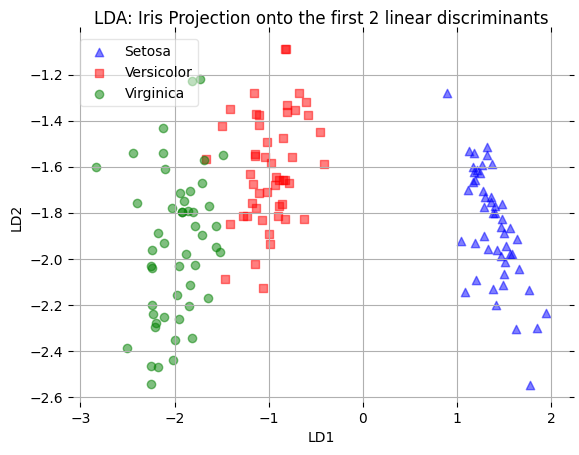

In [ ]:
def plot_step_lda():
    ax = plt.subplot(111)
    for label, marker, color in zip(
    range(0,3),("^", "s", "o"),("blue","red","green")):
        plt.scatter(x = X_lda[:,0].real[Y == label],
                   y= X_lda[:,1].real[Y ==label],
                   marker = marker,
                   color = color,
                   alpha = 0.5,
                   label = label_dict[label])
    plt.xlabel("LD1")
    plt.ylabel("LD2")

    leg = plt.legend(loc = "upper left", fancybox = True)
    leg.get_frame().set_alpha(0.5)
    plt.title("LDA: Iris Projection onto the first 2 linear discriminants")

    plt.tick_params(axis="both", which = "both", bottom = "off", top = "off",
                   labelbottom = "on", left = "off", right = "off", labelleft = "on")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    plt.grid()
    plt.tight_layout
    plt.show()

plot_step_lda()

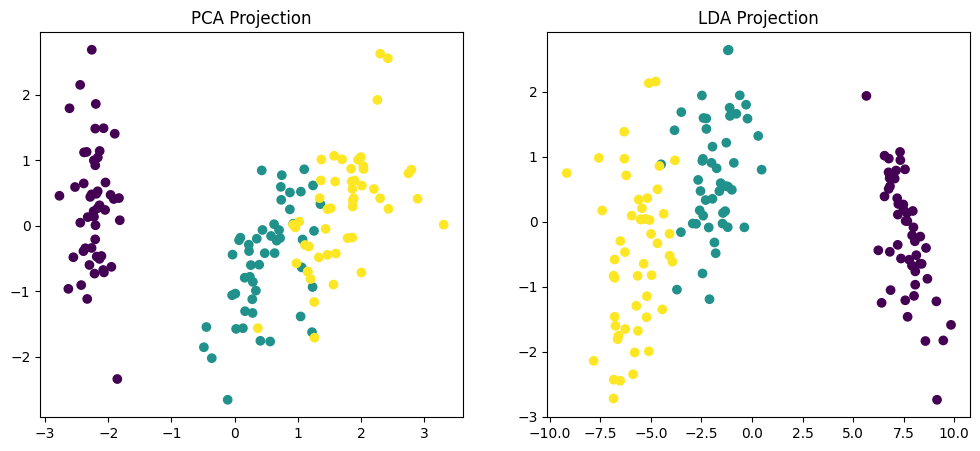

In [ ]:
from sklearn.decomposition import PCA

# PCA for comparison
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(12,5))

# PCA projection
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.title("PCA Projection")

# LDA projection
plt.subplot(1,2,2)
plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap='viridis')
plt.title("LDA Projection")

plt.show()


# **Step 1: Compute Class Means**

The **mean vector** of each class is central to computing scatter matrices.  
For each class `c`, with samples \( X_c \), the mean is:

\[
\mu_c = \frac{1}{N_c} \sum_{x \in X_c} x
\]

where  
- \( N_c \) = number of samples in class `c`  
- \( x \) = feature vector  

These class means are later used in calculating **within-class** and **between-class scatter**.


**Without LDA library inbuilt**

# Linear Discriminant Analysis (LDA)

**Aim:** Implement LDA manually without using inbuilt libraries.  
We will derive the LDA projection vector step by step using numerical computations, and visualize the data in both 2D and projected 1D space.

## Step 1: Import Libraries

We import **NumPy** for mathematical operations and **Matplotlib** for visualization.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Define Input Data

We create two classes (Class 1 and Class 2).  
Each class has **2 features** and **5 samples**.  
This will form the input dataset for LDA.


In [ ]:
# Example input: 2 features, 5 samples per class
x1 = np.array([[4, 2, 2, 3, 4],
               [1, 4, 3, 6, 4]])  # class 1

x2 = np.array([[9, 6, 9, 8, 10],
               [10, 8, 5, 7, 8]])  # class 2

## Step 3: Compute Class Means

We compute the **mean vector** for each class.  
The mean represents the centroid of the data points for that class.


In [ ]:
mean1 = np.mean(x1, axis=1).reshape(2, 1)
mean2 = np.mean(x2, axis=1).reshape(2, 1)

print("Mean μ1:\n", mean1)
print("Mean μ2:\n", mean2)

Mean μ1:
 [[3. ]
 [3.6]]
Mean μ2:
 [[8.4]
 [7.6]]


## Step 4: Compute Scatter Matrices

- For each class, we calculate the **scatter matrix** which measures how spread out the data points are.  
- Then we compute the **within-class scatter matrix (Sw)** by summing them.


In [ ]:
S1 = (x1 - mean1) @ (x1 - mean1).T
S2 = (x2 - mean2) @ (x2 - mean2).T

Sw = (S1 + S2) / 5
print("Within-class scatter Sw:\n", Sw)

Within-class scatter Sw:
 [[ 2.64 -0.44]
 [-0.44  5.28]]


## Step 5: Compute LDA Projection Vector

The LDA projection vector **w** is given by:

w=Sw^-1(μ1​−μ2​)
where μ1 is mean1 and μ2 is mean2

This vector defines the direction along which we project the data to maximize class separation.

In [ ]:
w = np.linalg.inv(Sw) @ (mean1 - mean2)
print("Projection vector w:\n", w)

Projection vector w:
 [[-2.20230474]
 [-0.94110115]]


## Step 6: Project Data onto LDA Vector

We now project all data points from both classes onto the vector `w`.  
This reduces our 2D data to **1D**, while preserving maximum class separability.


In [ ]:
x1_proj = (w.T @ x1).flatten()
x2_proj = (w.T @ x2).flatten()


## Step 7: Visualization

- **Left Plot:** Original 2D data with the LDA vector direction.  
- **Right Plot:** 1D projected data, showing the separation of the two classes.


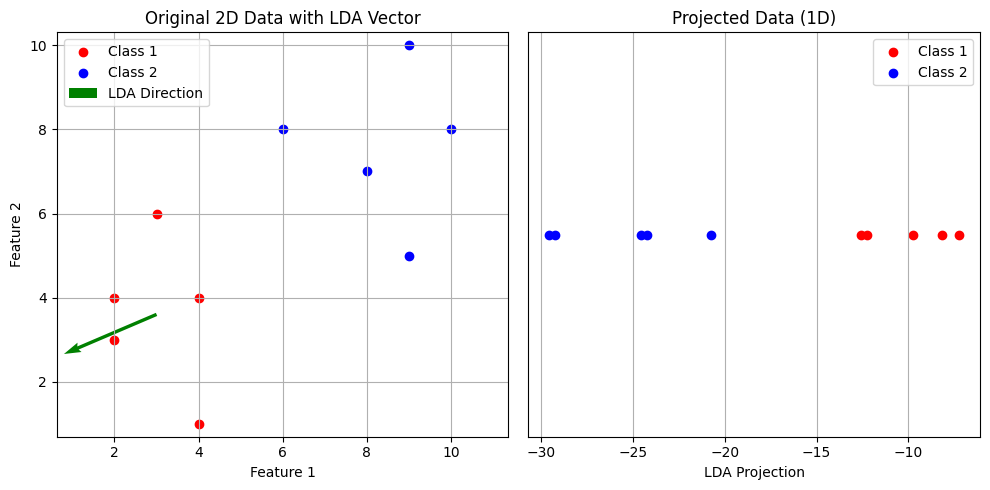

In [ ]:
plt.figure(figsize=(10, 5))

# Original data with LDA direction
plt.subplot(1, 2, 1)
plt.scatter(x1[0], x1[1], color='red', label='Class 1')
plt.scatter(x2[0], x2[1], color='blue', label='Class 2')
plt.quiver(*mean1.flatten(), *w.flatten(), scale=1, scale_units='xy', angles='xy',
           color='green', label='LDA Direction')
plt.title('Original 2D Data with LDA Vector')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.axis('equal')
plt.grid(True)

# Projected 1D data
plt.subplot(1, 2, 2)
plt.scatter(x1_proj, np.zeros_like(x1_proj), color='red', label='Class 1')
plt.scatter(x2_proj, np.zeros_like(x2_proj), color='blue', label='Class 2')
plt.title('Projected Data (1D)')
plt.xlabel('LDA Projection')
plt.yticks([])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Mean μ1:
 [[3. ]
 [3.6]]
Mean μ2:
 [[8.4]
 [7.6]]
Within-class scatter Sw:
 [[ 2.64 -0.44]
 [-0.44  5.28]]
Projection vector w:
 [[-2.20230474]
 [-0.94110115]]


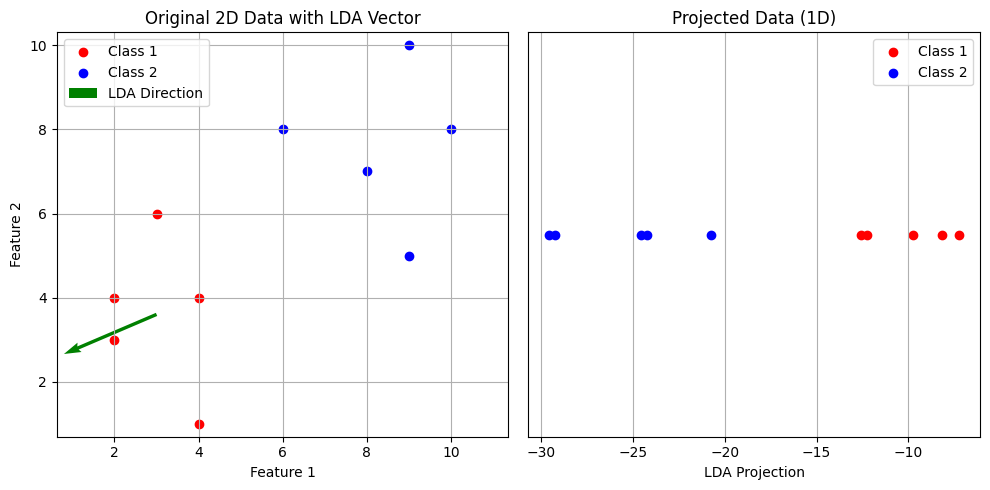

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example input: 2 features, 5 samples per class
# x1: class 1 samples (2x5)
x1 = np.array([[4, 2, 2, 3, 4],
               [1, 4, 3, 6, 4]])  # shape: (2,5)

# x2: class 2 samples (2x5)
x2 = np.array([[9, 6, 9, 8, 10],
               [10, 8, 5, 7, 8]])  # shape: (2,5)

# Step 1: Compute means
mean1 = np.mean(x1, axis=1).reshape(2, 1)  # column vector
mean2 = np.mean(x2, axis=1).reshape(2, 1)

print("Mean μ1:\n", mean1)
print("Mean μ2:\n", mean2)

# Step 2: Compute scatter matrices for each class
S1 = (x1 - mean1) @ (x1 - mean1).T
S2 = (x2 - mean2) @ (x2 - mean2).T

# Step 3: Total within-class scatter
Sw = (S1 + S2)/5
print("Within-class scatter Sw:\n", Sw)

# Step 4: Compute LDA projection vector w
w = np.linalg.inv(Sw) @ (mean1 - mean2)
print("Projection vector w:\n", w)

# Step 5: Project original points onto w
x1_proj = (w.T @ x1).flatten()
x2_proj = (w.T @ x2).flatten()

# Step 6: Plot original 2D data
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(x1[0], x1[1], color='red', label='Class 1')
plt.scatter(x2[0], x2[1], color='blue', label='Class 2')
plt.quiver(*mean1.flatten(), *w.flatten(), scale=1, scale_units='xy', angles='xy', color='green', label='LDA Direction')
plt.title('Original 2D Data with LDA Vector')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.axis('equal')
plt.grid(True)

# Step 7: Plot 1D projected data
plt.subplot(1, 2, 2)
plt.scatter(x1_proj, np.zeros_like(x1_proj), color='red', label='Class 1')
plt.scatter(x2_proj, np.zeros_like(x2_proj), color='blue', label='Class 2')
plt.title('Projected Data (1D)')
plt.xlabel('LDA Projection')
plt.yticks([])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
